In [5]:
!pip install google-play-scraper pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [7]:
"""
=============================================================
SCRAPING ULASAN NETFLIX - GOOGLE PLAY STORE
Target: 5.000 review per tahun (2022–2026) = ±25.000 total
=============================================================
CARA PAKAI:
  1. pip install google-play-scraper pandas
  2. Jalankan di laptop/PC sendiri (BUKAN Google Colab/cloud)
  3. Hasil disimpan otomatis ke: netflix_reviews_all.csv
=============================================================
"""

from google_play_scraper import reviews, Sort
import pandas as pd
import time
from datetime import datetime

# ── Konfigurasi ───────────────────────────────────────────
APP_ID         = 'com.netflix.mediaclient'
TARGET_PER_YEAR = 5_000
YEARS          = [2022, 2023, 2024, 2025, 2026]
BATCH_SIZE     = 200   # ambil 200 per request (maks library)
OUTPUT_FILE    = 'netflix_reviews_all.csv'

print("=" * 60)
print("  SCRAPING ULASAN NETFLIX - GOOGLE PLAY STORE")
print(f"  Target: {TARGET_PER_YEAR:,} review × {len(YEARS)} tahun")
print("=" * 60)

all_reviews = []

for year in YEARS:
    print(f"\n[Tahun {year}] Mulai scraping...")

    year_reviews = []
    continuation_token = None
    attempts = 0
    max_attempts = 300  # batas loop agar tidak infinite

    while len(year_reviews) < TARGET_PER_YEAR and attempts < max_attempts:
        try:
            result, continuation_token = reviews(
                APP_ID,
                lang='id',           # bahasa Indonesia
                country='id',        # dari Indonesia
                sort=Sort.NEWEST,
                count=BATCH_SIZE,
                continuation_token=continuation_token
            )

            if not result:
                print(f"  [!] Tidak ada data lagi untuk tahun {year}")
                break

            # Filter hanya review dari tahun target
            filtered = [
                r for r in result
                if r['at'].year == year
            ]

            # Cek apakah kita sudah melewati tahun target
            oldest_in_batch = min(r['at'].year for r in result)
            if oldest_in_batch < year:
                # Ambil yang masih dalam tahun target
                year_reviews.extend(filtered)
                print(f"  Sudah melewati tahun {year}, berhenti di sini.")
                break

            year_reviews.extend(filtered)
            attempts += 1

            # Progress
            pct = min(len(year_reviews) / TARGET_PER_YEAR * 100, 100)
            print(f"  Progress: {len(year_reviews):,}/{TARGET_PER_YEAR:,} "
                  f"({pct:.1f}%) | Batch #{attempts}", end='\r')

            # Rate limit agar tidak diblokir
            time.sleep(0.5)

            # Potong jika sudah cukup
            if len(year_reviews) >= TARGET_PER_YEAR:
                year_reviews = year_reviews[:TARGET_PER_YEAR]
                break

            # Jika token habis
            if continuation_token is None:
                print(f"\n  [!] Token habis, data terkumpul: {len(year_reviews):,}")
                break

        except Exception as e:
            print(f"\n  [!] Error: {e} — coba lagi dalam 5 detik...")
            time.sleep(5)
            attempts += 1
            continue

    print(f"\n  ✅ Tahun {year}: {len(year_reviews):,} reviews terkumpul")
    all_reviews.extend(year_reviews)

# ── Buat DataFrame ────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Total review terkumpul: {len(all_reviews):,}")

if not all_reviews:
    print("  [!] Tidak ada data. Pastikan dijalankan di laptop lokal!")
else:
    df = pd.DataFrame([{
        'review_id'   : r.get('reviewId', ''),
        'username'    : r.get('userName', ''),
        'rating'      : r.get('score', 0),
        'review_text' : r.get('content', ''),
        'thumbs_up'   : r.get('thumbsUpCount', 0),
        'app_version' : r.get('reviewCreatedVersion', ''),
        'timestamp'   : r.get('at', None),
        'year'        : r['at'].year if r.get('at') else None,
        'month'       : r['at'].month if r.get('at') else None,
    } for r in all_reviews])

    # Simpan ke CSV
    df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

    print(f"  ✅ Disimpan ke: {OUTPUT_FILE}")
    print(f"\n  Distribusi per tahun:")
    print(df['year'].value_counts().sort_index().to_string())
    print(f"\n  Distribusi rating:")
    print(df['rating'].value_counts().sort_index().to_string())
    print(f"\n  Contoh 3 baris pertama:")
    print(df[['username','rating','review_text','timestamp']].head(3).to_string())

print(f"\n{'='*60}")
print("  SCRAPING SELESAI")
print(f"{'='*60}")
print(f"\n  Langkah selanjutnya:")
print(f"  1. Upload file '{OUTPUT_FILE}' ke Claude")
print(f"  2. Minta analisis: cleaning, visualisasi, tren rating")


  SCRAPING ULASAN NETFLIX - GOOGLE PLAY STORE
  Target: 5,000 review × 5 tahun

[Tahun 2022] Mulai scraping...

  ✅ Tahun 2022: 5,000 reviews terkumpul

[Tahun 2023] Mulai scraping...

  ✅ Tahun 2023: 5,000 reviews terkumpul

[Tahun 2024] Mulai scraping...

  ✅ Tahun 2024: 5,000 reviews terkumpul

[Tahun 2025] Mulai scraping...

  ✅ Tahun 2025: 5,000 reviews terkumpul

[Tahun 2026] Mulai scraping...
  Sudah melewati tahun 2026, berhenti di sini.

  ✅ Tahun 2026: 2,210 reviews terkumpul

  Total review terkumpul: 22,210
  ✅ Disimpan ke: netflix_reviews_all.csv

  Distribusi per tahun:
year
2022    5000
2023    5000
2024    5000
2025    5000
2026    2210

  Distribusi rating:
rating
1    10496
2     1190
3     1138
4     1078
5     8308

  Contoh 3 baris pertama:
         username  rating                                    review_text           timestamp
0  Keyboard Vocal       3                PROVIDE FEATURE TO TURN OFF HDR 2022-12-31 18:47:55
1   Muhammad Yuda       1  Beberapa series

   BIG DATA ANALYTICS — NETFLIX GOOGLE PLAY STORE

─────────────────────────────────────────────────────────────────
  📦  KONSEP 1: VOLUME
─────────────────────────────────────────────────────────────────
  Total data mentah    : 22,210 reviews
  Periode data         : 2022-07-01 s/d 2026-04-24
  Jumlah kolom/atribut : 9 fitur
  Distribusi per tahun :
    2022 │ █████████████████████████ 5,000
    2023 │ █████████████████████████ 5,000
    2024 │ █████████████████████████ 5,000
    2025 │ █████████████████████████ 5,000
    2026 │ ███████████ 2,210

─────────────────────────────────────────────────────────────────
  🧹  KONSEP 2: VERACITY — DATA CLEANING
─────────────────────────────────────────────────────────────────
  [1] Hapus duplikat          : 0 dihapus → sisa 22,210
  [2] Hapus null/kosong       : 0 dihapus → sisa 22,210
  [3] Hapus terlalu pendek    : 589 dihapus → sisa 21,621
  [4] Hapus rating invalid    : 0 dihapus → sisa 21,621
  [5] Hapus simbol/angka saja : 145 dihapus → 

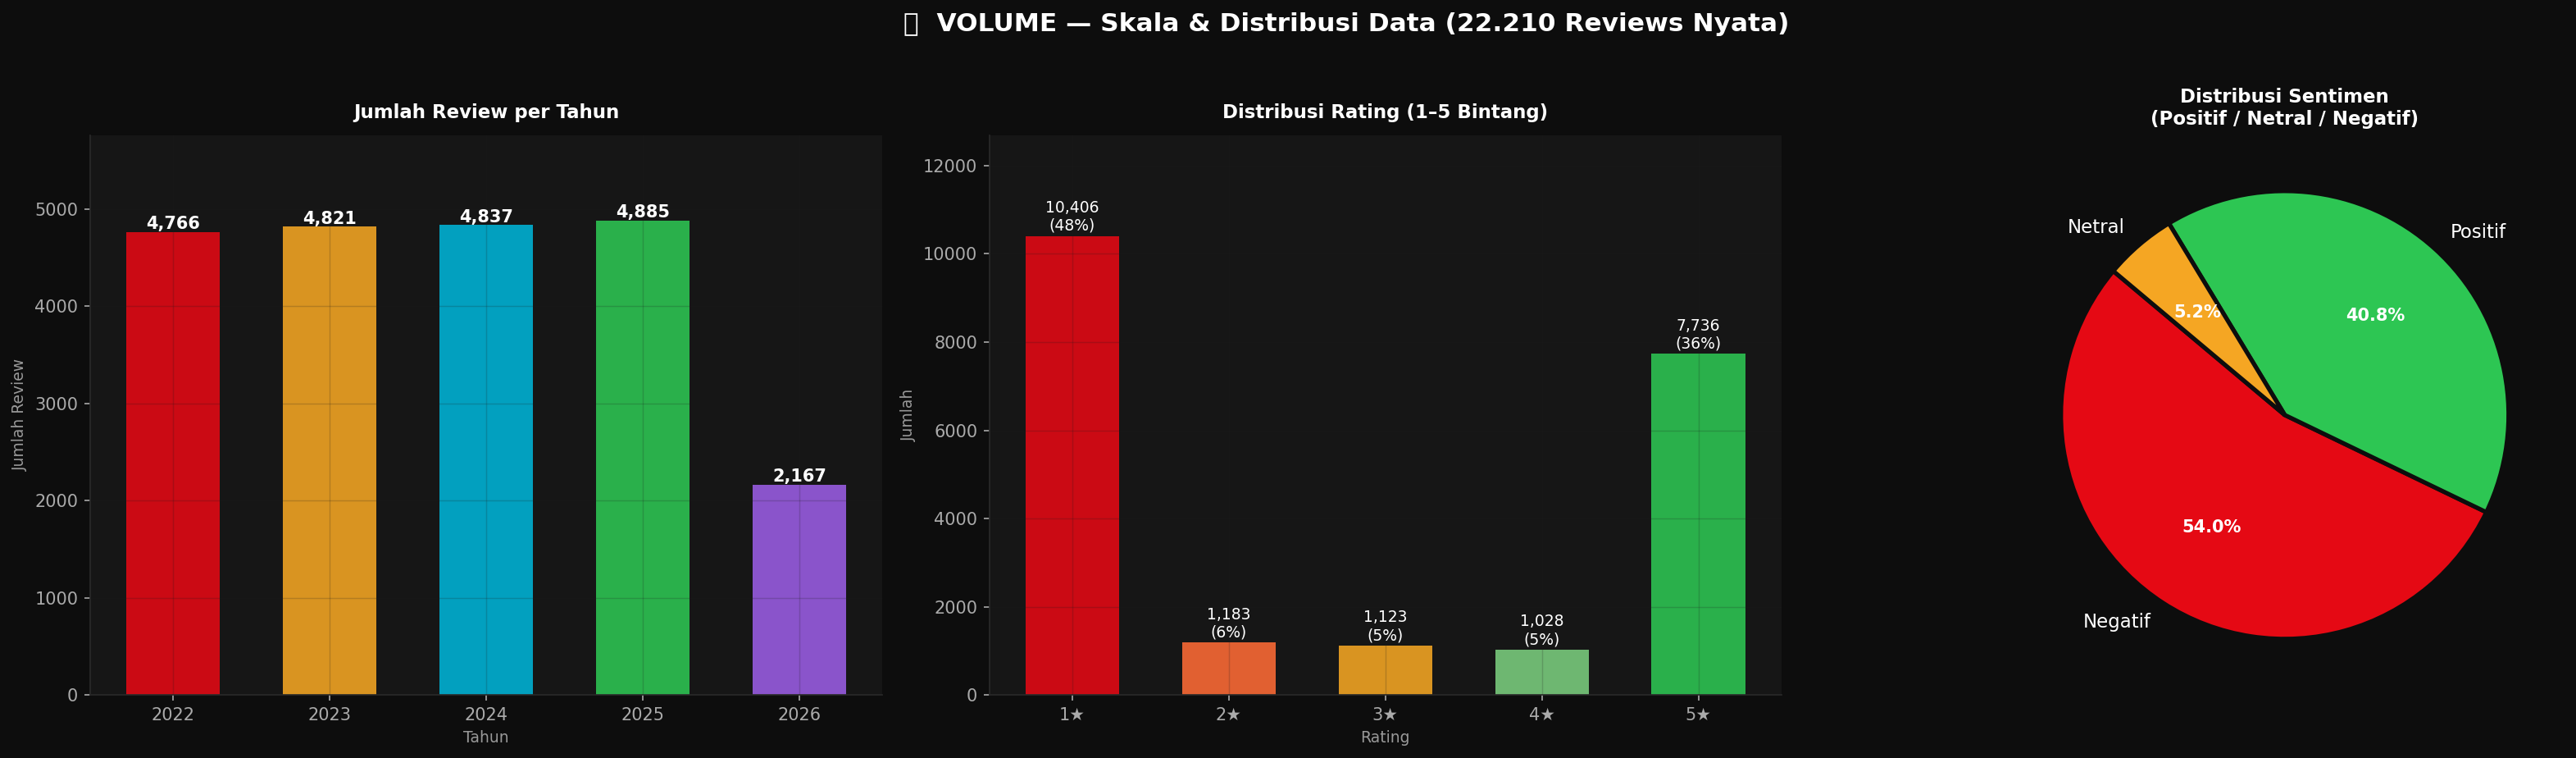


  netflix_2_velocity.png


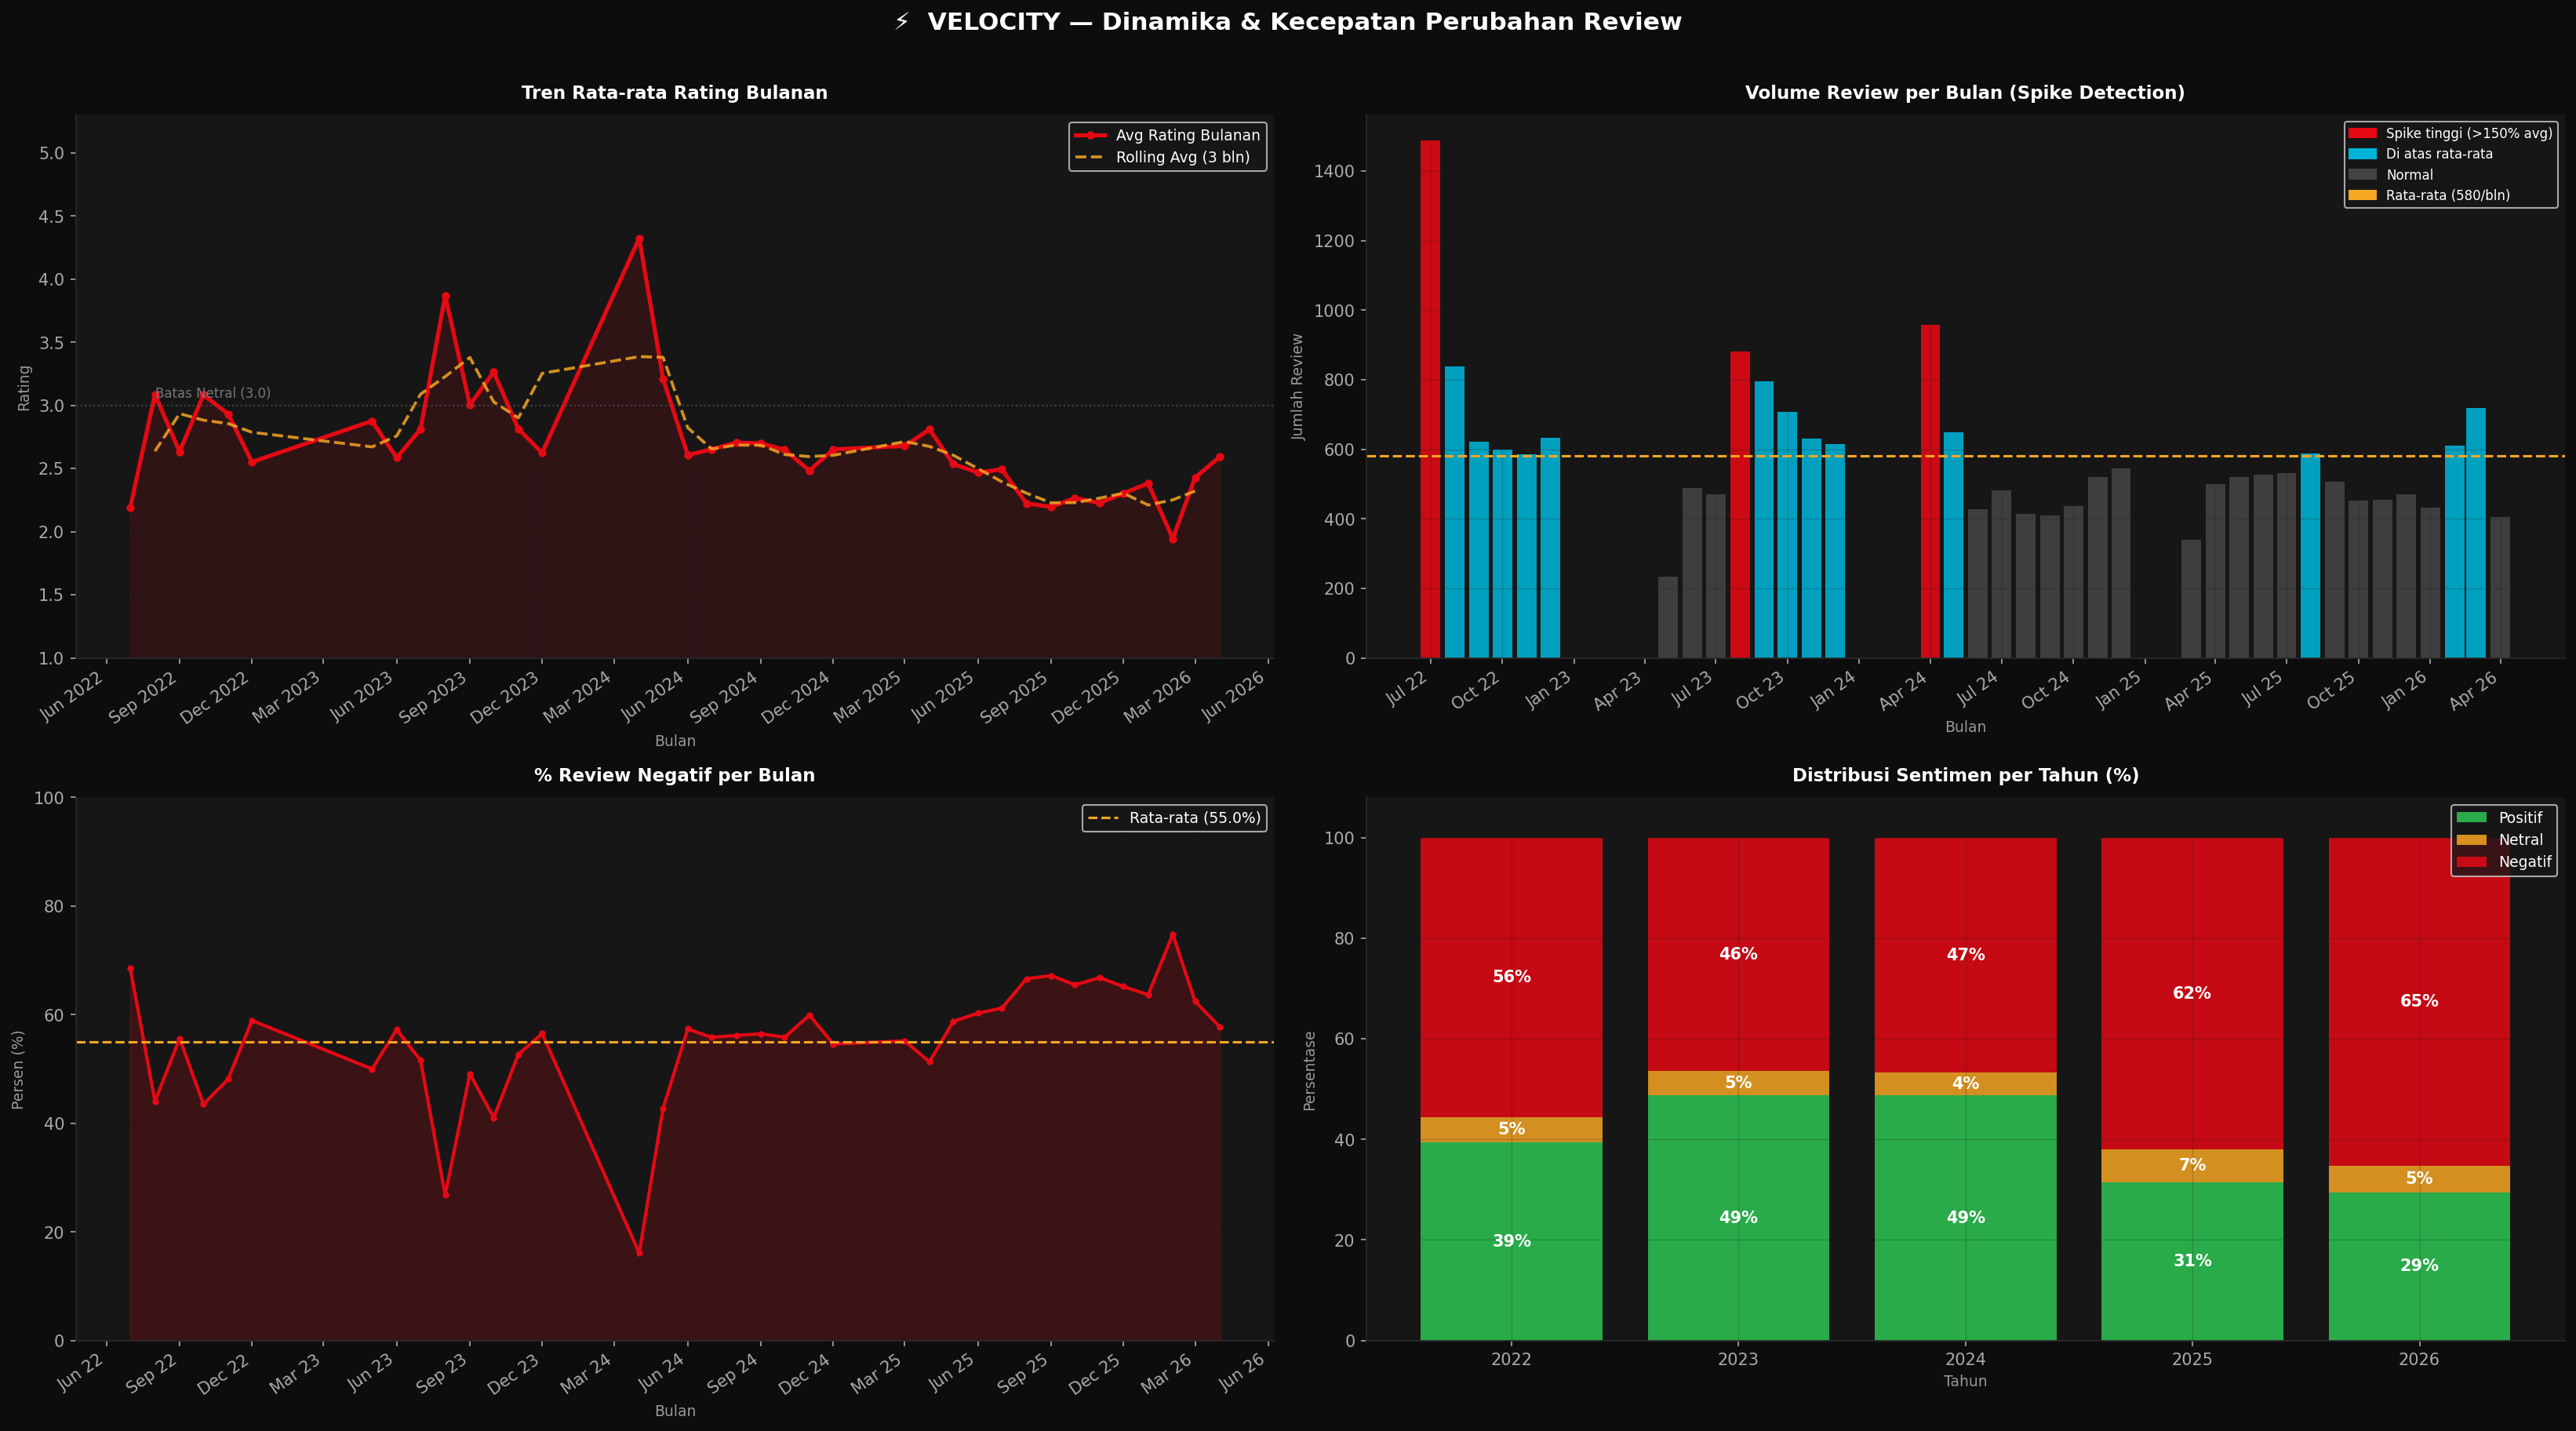


  netflix_3_veracity.png


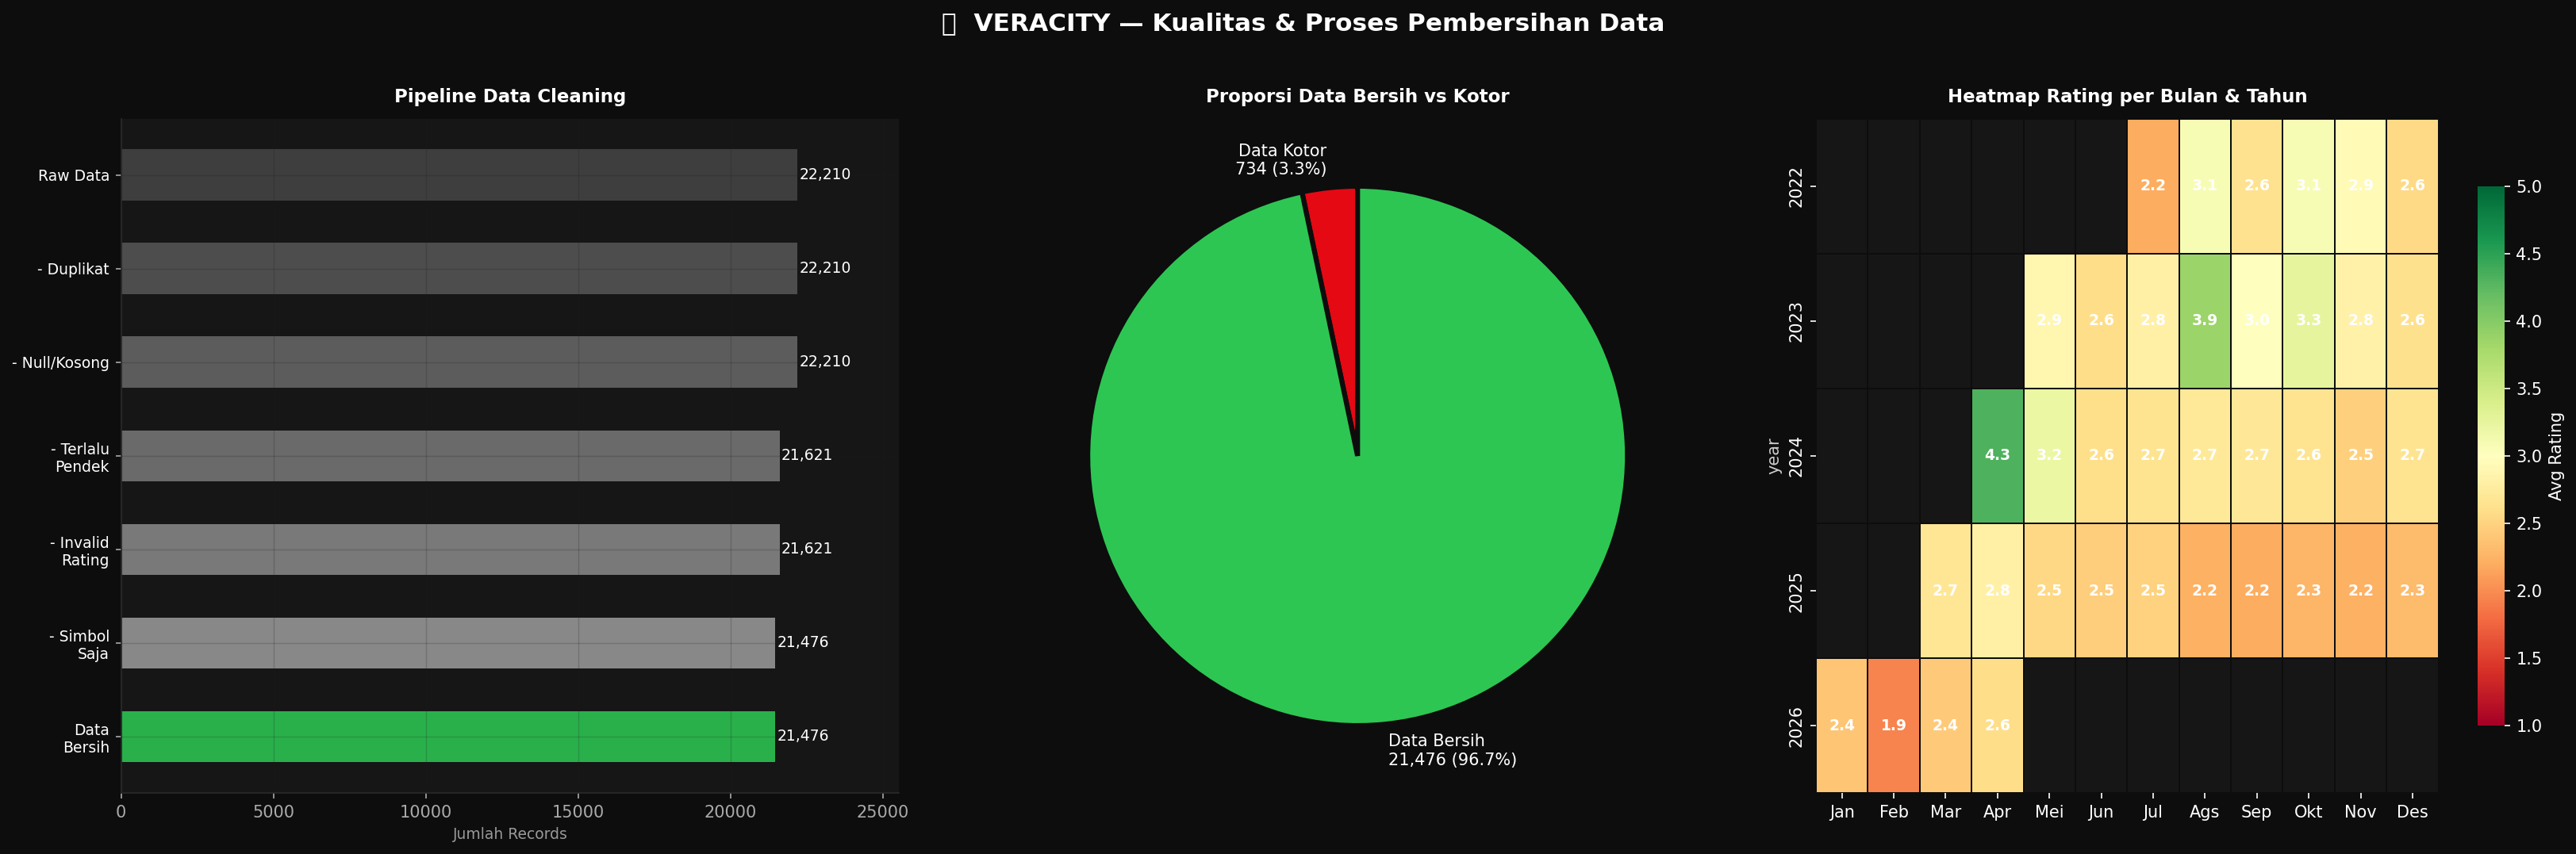


  netflix_4_insights.png


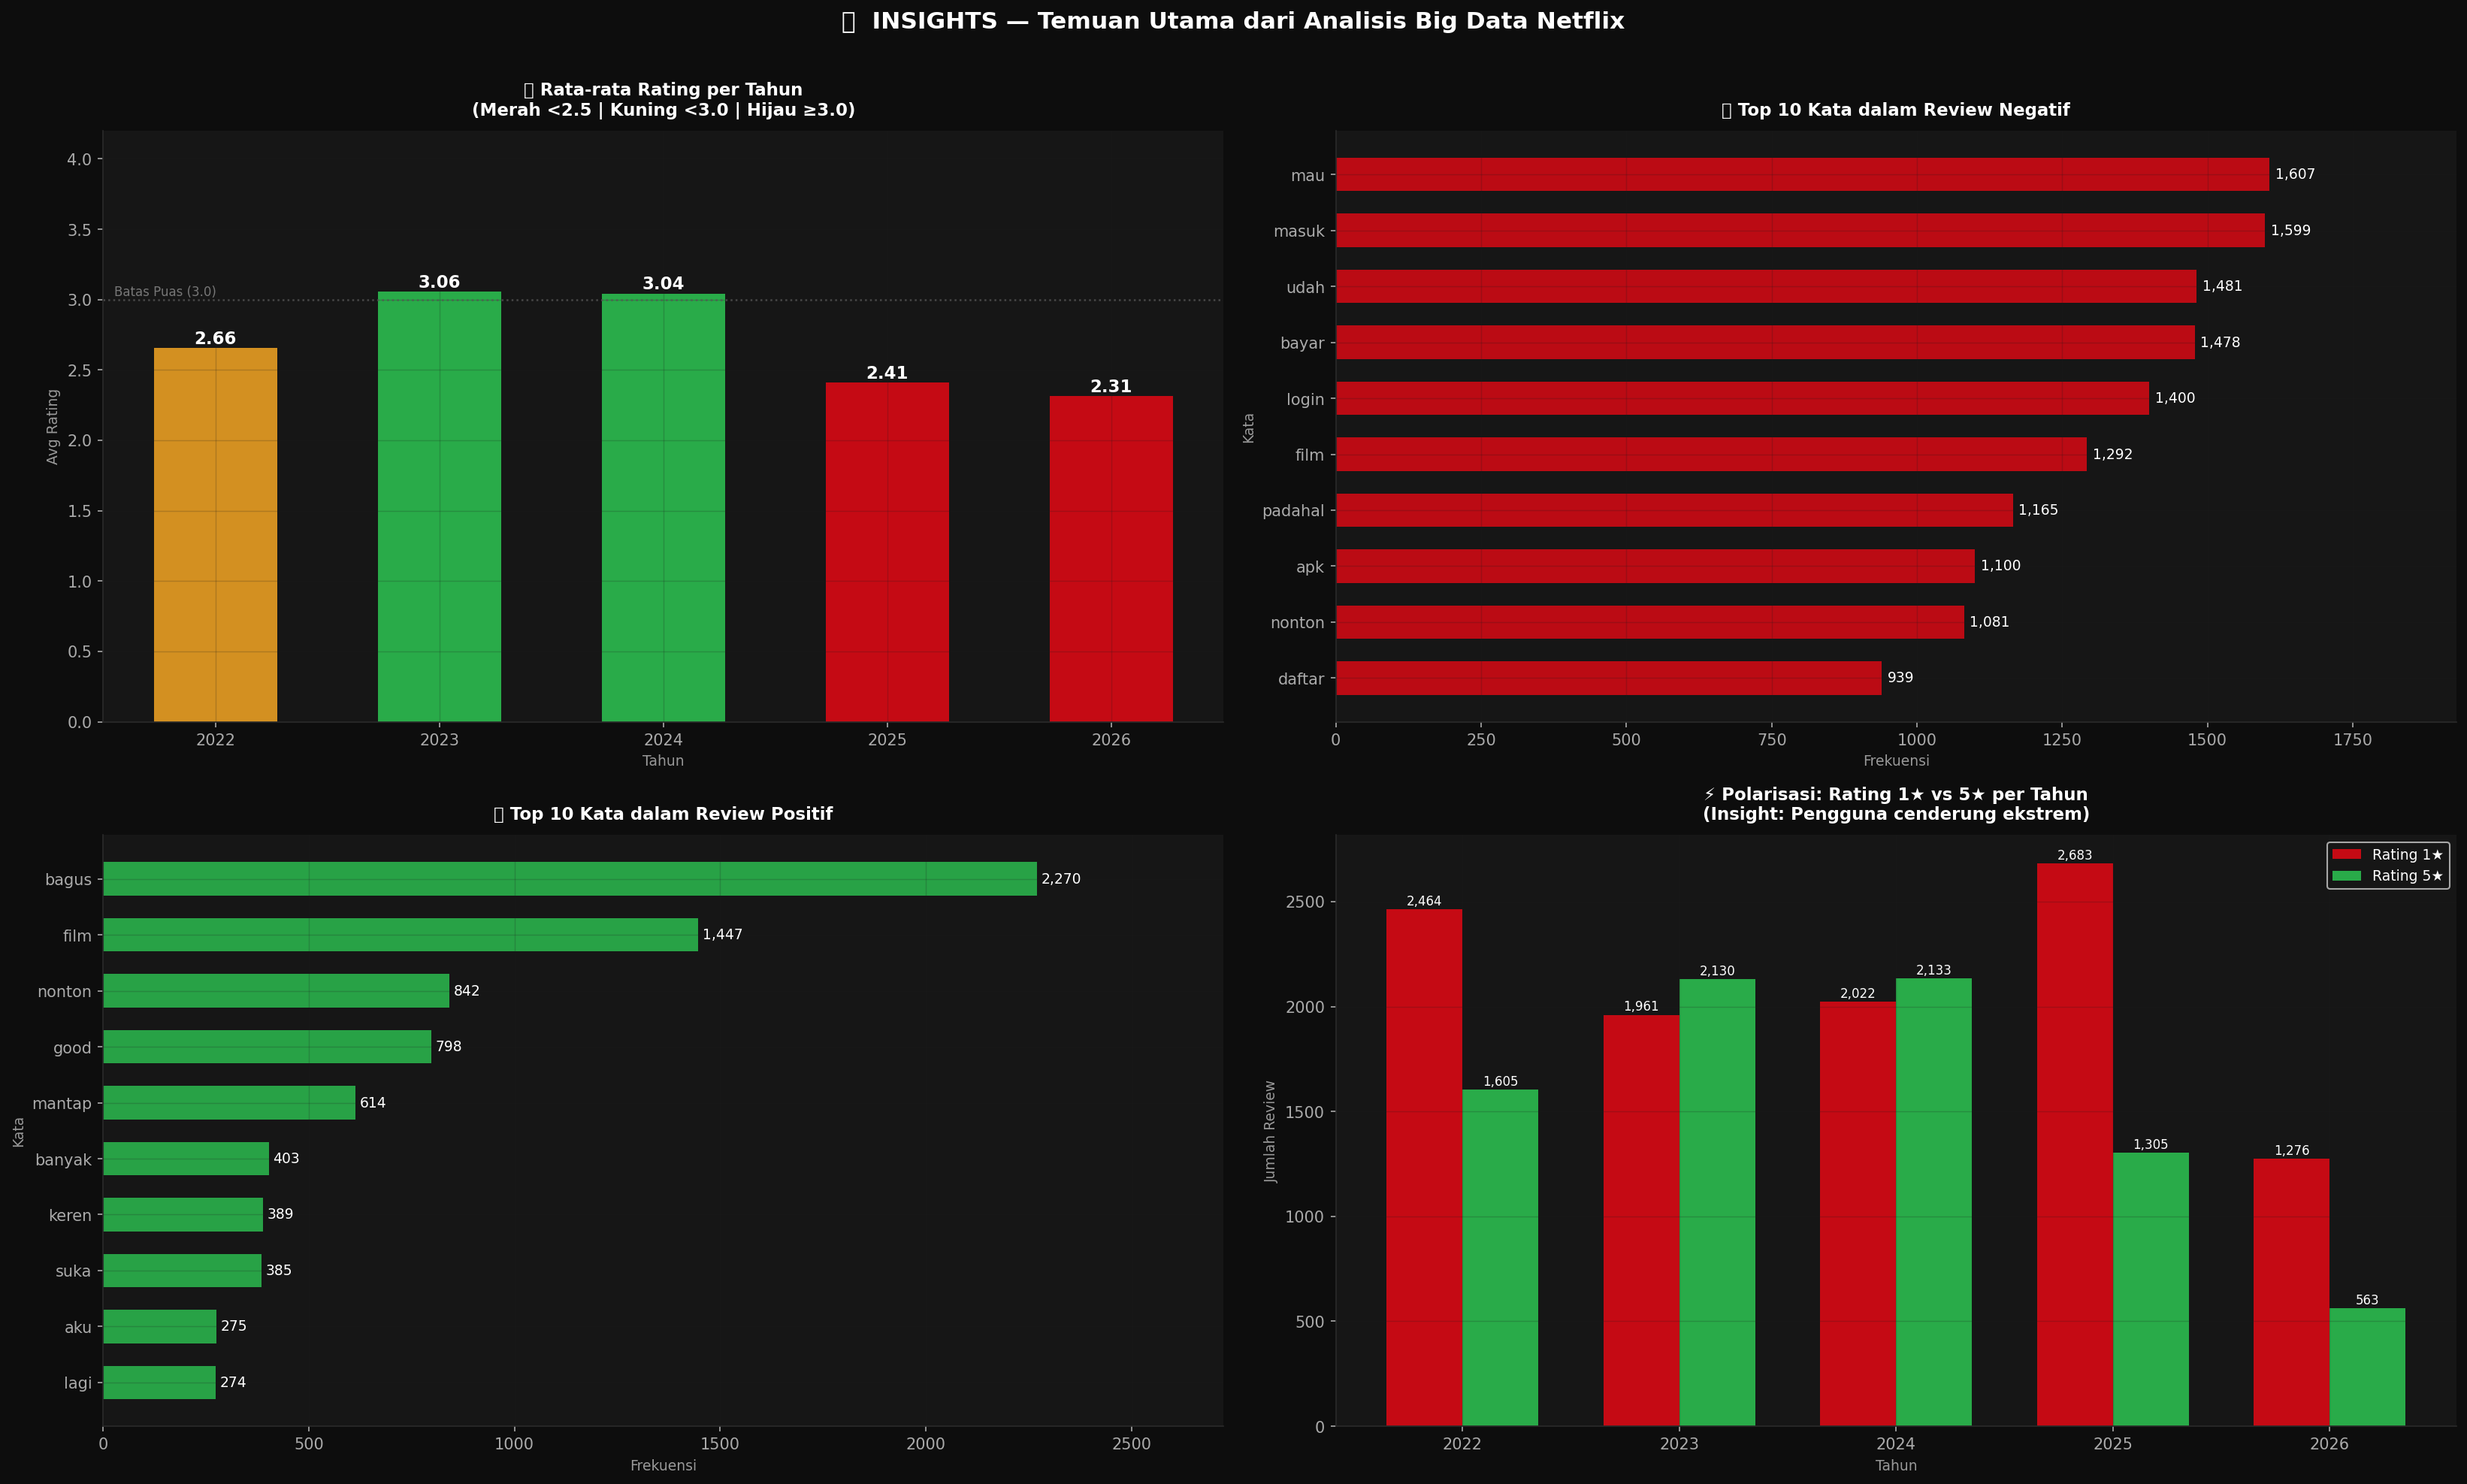


  netflix_5_wordcloud.png


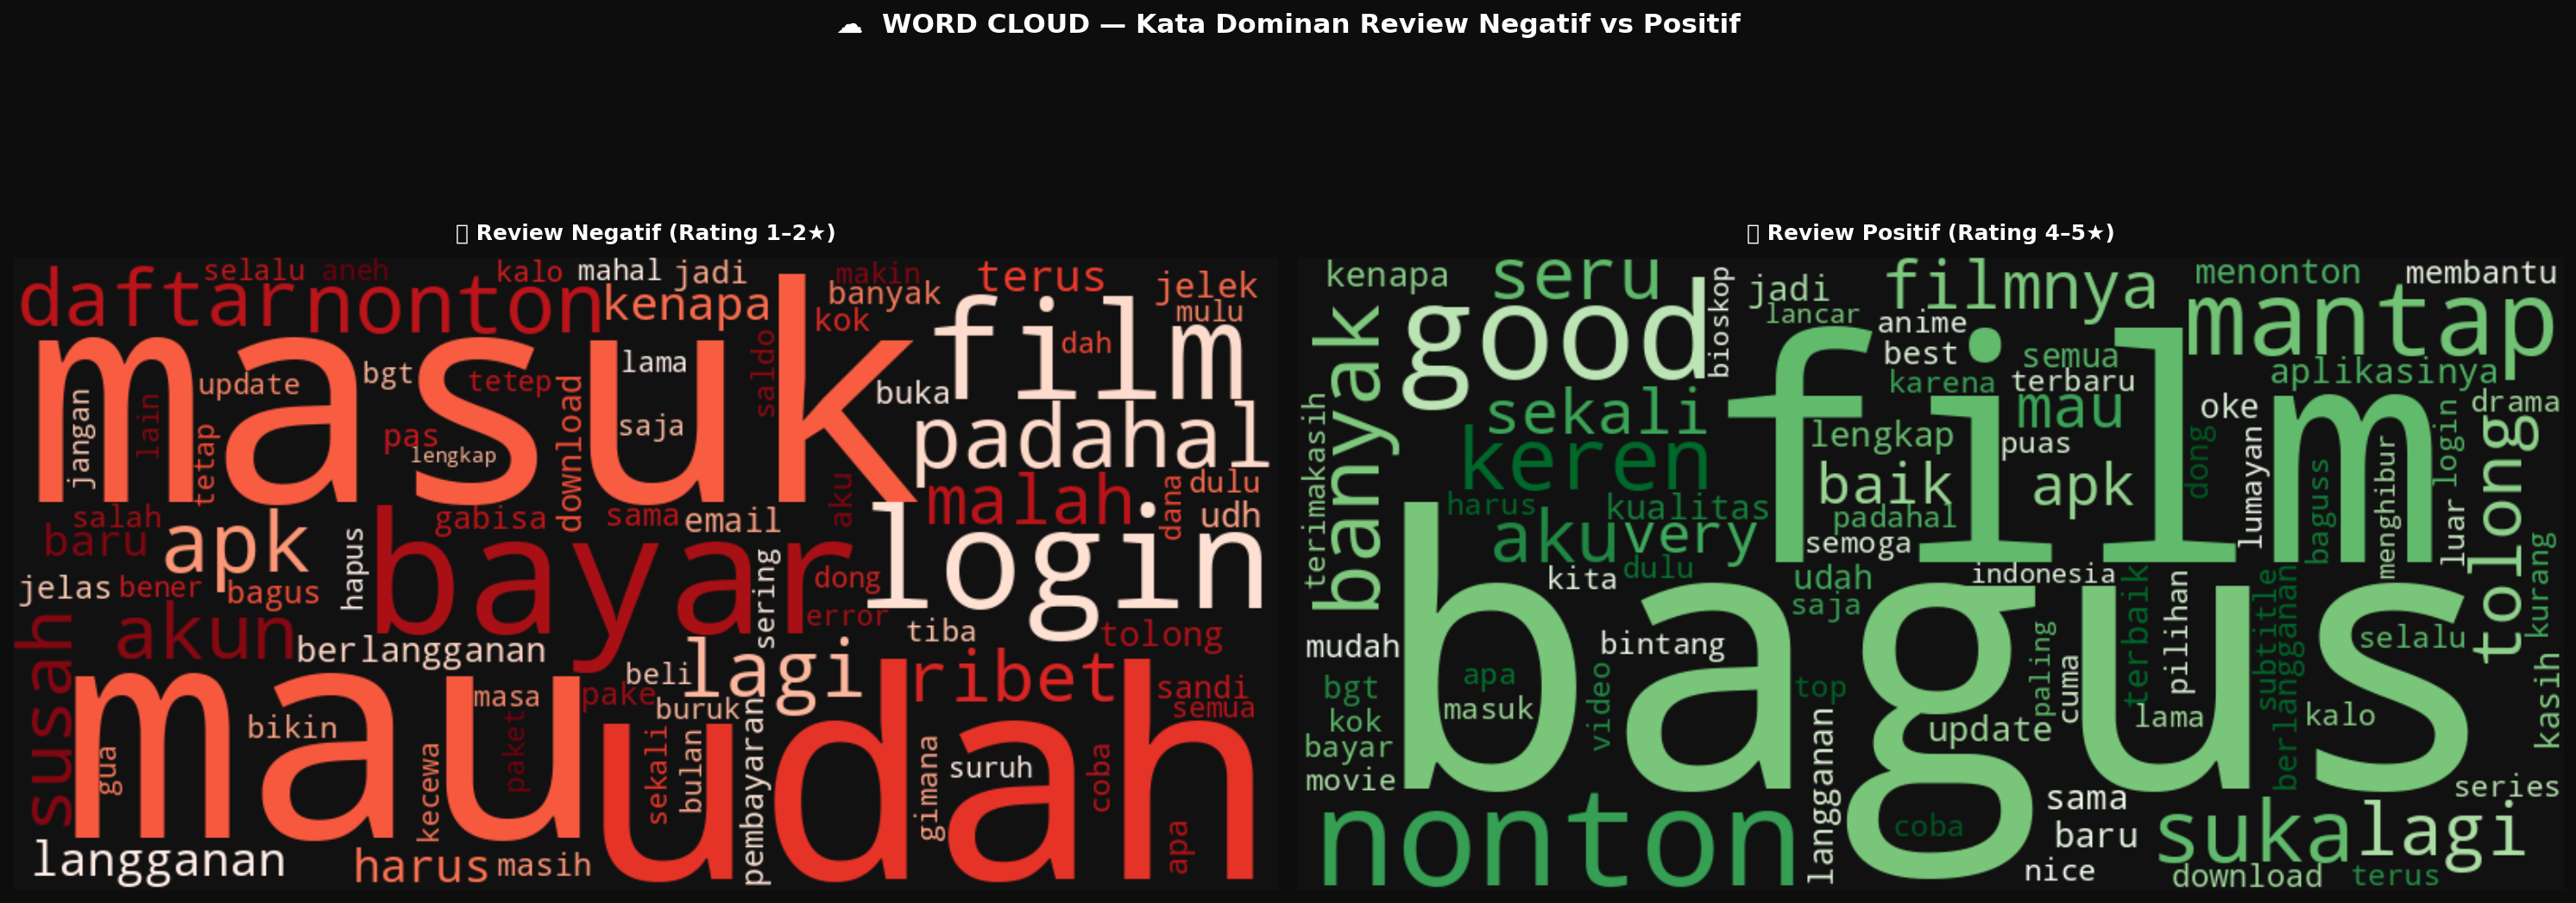

  5 file visualisasi tersimpan di: /content/
  • netflix_1_volume.png
  • netflix_2_velocity.png
  • netflix_3_veracity.png
  • netflix_4_insights.png
  • netflix_5_wordcloud.png

  SELESAI ✅


In [17]:
"""
=============================================================
BIG DATA ANALYTICS: ULASAN NETFLIX - GOOGLE PLAY STORE
Analisis Lengkap: Volume | Velocity | Veracity | Insights
=============================================================
"""
from IPython.display import Image, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
import os
warnings.filterwarnings('ignore')

# ── Style Global ──────────────────────────────────────────
plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'axes.facecolor' : '#111111',
    'figure.facecolor': '#0d0d0d',
    'text.color'     : 'white',
    'axes.labelcolor': '#cccccc',
    'xtick.color'    : '#aaaaaa',
    'ytick.color'    : '#aaaaaa',
    'axes.edgecolor' : '#2a2a2a',
    'grid.color'     : '#1e1e1e',
    'grid.linewidth' : 0.7,
})

RED    = '#E50914'
GOLD   = '#F5A623'
CYAN   = '#00B4D8'
GREEN  = '#2DC653'
PURPLE = '#9B5DE5'
BLUE   = '#1E88E5'
BG     = '#0d0d0d'
CARD   = '#161616'
OUTPUT = '/content'
os.makedirs(OUTPUT, exist_ok=True)

def style_ax(ax, title, xlabel='', ylabel='', grid=True):
    ax.set_facecolor(CARD)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color='#999999', fontsize=9)
    ax.set_ylabel(ylabel, color='#999999', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if grid:
        ax.grid(True, alpha=0.2)

# =============================================================
# LOAD DATA
# =============================================================
print("=" * 65)
print("   BIG DATA ANALYTICS — NETFLIX GOOGLE PLAY STORE")
print("=" * 65)

df_raw = pd.read_csv('netflix_reviews_all.csv')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
n_raw = len(df_raw)

print(f"\n{'─'*65}")
print(f"  📦  KONSEP 1: VOLUME")
print(f"{'─'*65}")
print(f"  Total data mentah    : {n_raw:,} reviews")
print(f"  Periode data         : {df_raw['timestamp'].min().date()} s/d {df_raw['timestamp'].max().date()}")
print(f"  Jumlah kolom/atribut : {len(df_raw.columns)} fitur")
print(f"  Distribusi per tahun :")
for yr, cnt in df_raw['year'].value_counts().sort_index().items():
    bar = '█' * int(cnt / 200)
    print(f"    {yr} │ {bar} {cnt:,}")

# =============================================================
# KONSEP 2: VERACITY — DATA CLEANING
# =============================================================
print(f"\n{'─'*65}")
print(f"  🧹  KONSEP 2: VERACITY — DATA CLEANING")
print(f"{'─'*65}")

df = df_raw.copy()
pipeline = []

# Step 1: Duplikat
n0 = len(df)
df = df.drop_duplicates(subset=['review_id'])
n_dup = n0 - len(df)
pipeline.append(('Hapus duplikat (review_id)', n0, len(df), n_dup))
print(f"  [1] Hapus duplikat          : {n_dup:,} dihapus → sisa {len(df):,}")

# Step 2: Null / kosong
n1 = len(df)
df = df.dropna(subset=['review_text', 'rating'])
df = df[df['review_text'].str.strip() != '']
n_null = n1 - len(df)
pipeline.append(('Hapus null/kosong', n1, len(df), n_null))
print(f"  [2] Hapus null/kosong       : {n_null:,} dihapus → sisa {len(df):,}")

# Step 3: Terlalu pendek
n2 = len(df)
df = df[df['review_text'].str.len() >= 3]
n_short = n2 - len(df)
pipeline.append(('Hapus terlalu pendek (<3 chr)', n2, len(df), n_short))
print(f"  [3] Hapus terlalu pendek    : {n_short:,} dihapus → sisa {len(df):,}")

# Step 4: Rating tidak valid
n3 = len(df)
df = df[df['rating'].between(1, 5)]
n_invalid = n3 - len(df)
pipeline.append(('Hapus rating tidak valid', n3, len(df), n_invalid))
print(f"  [4] Hapus rating invalid    : {n_invalid:,} dihapus → sisa {len(df):,}")

# Step 5: Hanya simbol/angka
n4 = len(df)
df = df[df['review_text'].apply(lambda t: bool(re.search(r'[a-zA-Z\u00C0-\u024F]', str(t))))]
n_symbol = n4 - len(df)
pipeline.append(('Hapus simbol/angka saja', n4, len(df), n_symbol))
print(f"  [5] Hapus simbol/angka saja : {n_symbol:,} dihapus → sisa {len(df):,}")

n_clean   = len(df)
n_removed = n_raw - n_clean
pct_clean = n_clean / n_raw * 100

print(f"\n  ✅ Data bersih final : {n_clean:,} records ({pct_clean:.1f}% valid)")
print(f"  🗑️  Total dihapus     : {n_removed:,} records ({100-pct_clean:.1f}% noise)")

# Kolom turunan
df['month_dt'] = df['timestamp'].dt.to_period('M').dt.to_timestamp()
df['week_dt']  = df['timestamp'].dt.to_period('W').dt.to_timestamp()
df['sentimen'] = df['rating'].apply(
    lambda r: 'Positif' if r >= 4 else ('Netral' if r == 3 else 'Negatif'))

# =============================================================
# KONSEP 3: VELOCITY
# =============================================================
print(f"\n{'─'*65}")
print(f"  ⚡  KONSEP 3: VELOCITY")
print(f"{'─'*65}")

vel_weekly  = df.groupby('week_dt').size().reset_index(name='count')
vel_monthly = df.groupby('month_dt').agg(
    avg_rating  = ('rating', 'mean'),
    total       = ('rating', 'count'),
    pct_neg     = ('sentimen', lambda x: (x=='Negatif').sum()/len(x)*100)
).reset_index()

avg_weekly = vel_weekly['count'].mean()
peak       = vel_weekly.loc[vel_weekly['count'].idxmax()]
busiest_mo = vel_monthly.loc[vel_monthly['total'].idxmax()]

print(f"  Rata-rata review/minggu  : {avg_weekly:.0f}")
print(f"  Puncak spike             : {peak['count']:,} ({peak['week_dt'].strftime('%b %Y')}) — {peak['count']/avg_weekly:.1f}× rata-rata")
print(f"  Bulan tersibuk           : {busiest_mo['month_dt'].strftime('%B %Y')} ({busiest_mo['total']:,} reviews)")
print(f"  Total minggu terekam     : {len(vel_weekly):,} minggu")
print(f"\n  Velocity per tahun:")
vel_yr = df.groupby('year').size()
for yr, cnt in vel_yr.items():
    rate = cnt / 52
    print(f"    {yr} → {cnt:,} reviews ({rate:.0f}/minggu rata-rata)")

# =============================================================
# INSIGHTS
# =============================================================
print(f"\n{'─'*65}")
print(f"  💡  INSIGHTS")
print(f"{'─'*65}")

avg_rating = df['rating'].mean()
yr_avg = df.groupby('year')['rating'].mean()
sent_dist = df['sentimen'].value_counts()

# Kata kunci negatif
stop_words = {'yang','di','dan','ini','itu','dengan','tidak','ada','saya','untuk',
              'ke','dari','pada','atau','juga','sudah','tapi','bisa','lebih',
              'sangat','banget','app','aplikasi','netflix','the','is','and','to',
              'of','a','in','i','it','my','me','but','so','be','an','are',
              'have','has','can','was','not','this','that','for','with','im',
              'nya','aja','gak','ga','sih','deh','lah','ya','kali','kalau','buat'}

neg_words = []
pos_words = []
for _, row in df.iterrows():
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(row['review_text']).lower())
    words = [w for w in words if w not in stop_words]
    if row['sentimen'] == 'Negatif':
        neg_words.extend(words)
    elif row['sentimen'] == 'Positif':
        pos_words.extend(words)

top_neg = Counter(neg_words).most_common(10)
top_pos = Counter(pos_words).most_common(10)

print(f"\n  Rating rata-rata keseluruhan : {avg_rating:.2f} / 5.00")
print(f"  Sentimen dominan            : {sent_dist.idxmax()} ({sent_dist.max():,} — {sent_dist.max()/n_clean*100:.1f}%)")
print(f"  Tahun terbaik               : {yr_avg.idxmax()} (avg {yr_avg.max():.2f})")
print(f"  Tahun terburuk              : {yr_avg.idxmin()} (avg {yr_avg.min():.2f})")
print(f"  Polarisasi rating           : {(df['rating']==1).sum():,} rating 1★ vs {(df['rating']==5).sum():,} rating 5★")
print(f"\n  Top 10 kata dalam review NEGATIF:")
for w, c in top_neg:
    print(f"    '{w}' → {c:,}×")
print(f"\n  Top 10 kata dalam review POSITIF:")
for w, c in top_pos:
    print(f"    '{w}' → {c:,}×")

# =============================================================
# ══ GAMBAR 1: VOLUME ══
# =============================================================
print(f"\n{'─'*65}")
print(f"  🎨  Membuat visualisasi...")
print(f"{'─'*65}")

fig1, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor=BG)
fig1.suptitle('📦  VOLUME — Skala & Distribusi Data (22.210 Reviews Nyata)',
              fontsize=15, fontweight='bold', color='white', y=1.02)

# 1a. Volume per tahun
ax = axes[0]
yr_cnt = df['year'].value_counts().sort_index()
bars = ax.bar(yr_cnt.index.astype(str), yr_cnt.values,
              color=[RED, GOLD, CYAN, GREEN, PURPLE], alpha=0.88, width=0.6)
for bar, val in zip(bars, yr_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{val:,}', ha='center', color='white', fontsize=10, fontweight='bold')
style_ax(ax, 'Jumlah Review per Tahun', 'Tahun', 'Jumlah Review')
ax.set_ylim(0, yr_cnt.max()*1.18)

# 1b. Distribusi rating
ax = axes[1]
rc = df['rating'].value_counts().sort_index()
clrs = [RED,'#FF6B35',GOLD,'#7BCF7E',GREEN]
bars = ax.bar([f'{r}★' for r in rc.index], rc.values, color=clrs, alpha=0.88, width=0.6)
for bar, val in zip(bars, rc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/n_clean*100:.0f}%)',
            ha='center', va='bottom', color='white', fontsize=9)
style_ax(ax, 'Distribusi Rating (1–5 Bintang)', 'Rating', 'Jumlah')
ax.set_ylim(0, rc.max()*1.22)

# 1c. Distribusi sentimen (pie)
ax = axes[2]
sd = df['sentimen'].value_counts()
colors_pie = [RED, GREEN, GOLD]
wedges, texts, autotexts = ax.pie(
    sd.values, labels=sd.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    textprops={'color':'white','fontsize':11},
    wedgeprops={'edgecolor':BG,'linewidth':2.5}
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax.set_title('Distribusi Sentimen\n(Positif / Netral / Negatif)',
             color='white', fontsize=11, fontweight='bold')
ax.set_facecolor(CARD)

plt.tight_layout()
p1 = os.path.join(OUTPUT, 'netflix_1_volume.png')
fig1.savefig(p1, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig1)
print(f"  ✅ Gambar 1 (Volume)   : {p1}")

# =============================================================
# ══ GAMBAR 2: VELOCITY ══
# =============================================================
fig2, axes = plt.subplots(2, 2, figsize=(22, 12), facecolor=BG)
fig2.suptitle('⚡  VELOCITY — Dinamika & Kecepatan Perubahan Review',
              fontsize=15, fontweight='bold', color='white', y=1.01)

# 2a. Tren rating bulanan
ax = axes[0,0]
ax.fill_between(vel_monthly['month_dt'], vel_monthly['avg_rating'],
                alpha=0.12, color=RED)
ax.plot(vel_monthly['month_dt'], vel_monthly['avg_rating'],
        color=RED, lw=2.5, marker='o', ms=4, label='Avg Rating Bulanan')
roll = vel_monthly['avg_rating'].rolling(3, center=True).mean()
ax.plot(vel_monthly['month_dt'], roll,
        color=GOLD, lw=1.8, ls='--', alpha=0.85, label='Rolling Avg (3 bln)')
ax.axhline(3, color='#555', lw=1, ls=':', alpha=0.7)
ax.text(vel_monthly['month_dt'].iloc[1], 3.06,
        'Batas Netral (3.0)', color='#777', fontsize=8)
ax.set_ylim(1, 5.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
style_ax(ax, 'Tren Rata-rata Rating Bulanan', 'Bulan', 'Rating')
ax.legend(facecolor=CARD, labelcolor='white', fontsize=9)

# 2b. Volume review per bulan (velocity)
ax = axes[0,1]
mean_vol = vel_monthly['total'].mean()
bar_clrs = [RED if v > mean_vol*1.5 else (CYAN if v > mean_vol else '#444')
            for v in vel_monthly['total']]
ax.bar(vel_monthly['month_dt'], vel_monthly['total'],
       color=bar_clrs, width=25, alpha=0.88)
ax.axhline(mean_vol, color=GOLD, lw=1.5, ls='--',
           label=f'Rata-rata ({mean_vol:.0f}/bln)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
style_ax(ax, 'Volume Review per Bulan (Spike Detection)', 'Bulan', 'Jumlah Review')
ax.legend(handles=[
    mpatches.Patch(color=RED,  label='Spike tinggi (>150% avg)'),
    mpatches.Patch(color=CYAN, label='Di atas rata-rata'),
    mpatches.Patch(color='#444', label='Normal'),
    mpatches.Patch(color=GOLD, label=f'Rata-rata ({mean_vol:.0f}/bln)'),
], facecolor=CARD, labelcolor='white', fontsize=8)

# 2c. % sentimen negatif per bulan
ax = axes[1,0]
ax.fill_between(vel_monthly['month_dt'], vel_monthly['pct_neg'],
                alpha=0.18, color=RED)
ax.plot(vel_monthly['month_dt'], vel_monthly['pct_neg'],
        color=RED, lw=2, marker='o', ms=3)
ax.axhline(vel_monthly['pct_neg'].mean(), color=GOLD, lw=1.5, ls='--',
           label=f"Rata-rata ({vel_monthly['pct_neg'].mean():.1f}%)")
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
style_ax(ax, '% Review Negatif per Bulan', 'Bulan', 'Persen (%)')
ax.legend(facecolor=CARD, labelcolor='white', fontsize=9)

# 2d. Sentimen stacked per tahun
ax = axes[1,1]
sent_yr = df.groupby(['year','sentimen']).size().unstack(fill_value=0)
sent_pct = sent_yr.div(sent_yr.sum(axis=1), axis=0)*100
bottom = np.zeros(len(sent_pct))
for col, clr in [('Positif',GREEN),('Netral',GOLD),('Negatif',RED)]:
    if col in sent_pct.columns:
        bars_s = ax.bar(sent_pct.index.astype(str), sent_pct[col],
                        bottom=bottom, color=clr, label=col, alpha=0.85)
        for bar, bot, val in zip(bars_s, bottom, sent_pct[col]):
            if val > 4:
                ax.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                        f'{val:.0f}%', ha='center', va='center',
                        color='white', fontsize=10, fontweight='bold')
        bottom += sent_pct[col].values
style_ax(ax, 'Distribusi Sentimen per Tahun (%)', 'Tahun', 'Persentase')
ax.set_ylim(0, 108)
ax.legend(facecolor=CARD, labelcolor='white', fontsize=9, loc='upper right')

plt.tight_layout()
p2 = os.path.join(OUTPUT, 'netflix_2_velocity.png')
fig2.savefig(p2, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig2)
print(f"  ✅ Gambar 2 (Velocity) : {p2}")

# =============================================================
# ══ GAMBAR 3: VERACITY ══
# =============================================================
fig3, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG)
fig3.suptitle('🧹  VERACITY — Kualitas & Proses Pembersihan Data',
              fontsize=15, fontweight='bold', color='white', y=1.02)

# 3a. Pipeline cleaning (waterfall)
ax = axes[0]
step_labels = ['Raw Data','- Duplikat','- Null/Kosong','- Terlalu\nPendek','- Invalid\nRating','- Simbol\nSaja','Data\nBersih']
step_vals   = [n_raw, n_raw-n_dup, n_raw-n_dup-n_null,
               n_raw-n_dup-n_null-n_short,
               n_raw-n_dup-n_null-n_short-n_invalid,
               n_clean, n_clean]
bar_clrs3 = ['#444','#555','#666','#777','#888','#999',GREEN]
bars = ax.barh(range(len(step_labels)), step_vals,
               color=bar_clrs3, height=0.55, alpha=0.88)
for bar, val in zip(bars, step_vals):
    ax.text(val+50, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9)
ax.set_yticks(range(len(step_labels)))
ax.set_yticklabels(step_labels, color='white', fontsize=9)
ax.invert_yaxis()
style_ax(ax, 'Pipeline Data Cleaning', 'Jumlah Records', '')
ax.set_xlim(0, n_raw*1.15)

# 3b. Proporsi data bersih vs kotor
ax = axes[1]
sizes  = [n_removed, n_clean]
labels = [f'Data Kotor\n{n_removed:,} ({100-pct_clean:.1f}%)',
          f'Data Bersih\n{n_clean:,} ({pct_clean:.1f}%)']
wedges, texts = ax.pie(sizes, labels=labels, colors=[RED, GREEN],
                       startangle=90,
                       textprops={'color':'white','fontsize':10},
                       wedgeprops={'edgecolor':BG,'linewidth':3})
ax.set_title('Proporsi Data Bersih vs Kotor',
             color='white', fontsize=11, fontweight='bold', pad=10)
ax.set_facecolor(CARD)

# 3c. Heatmap rating per bulan & tahun
ax = axes[2]
pivot = df.groupby(['year','month'])['rating'].mean().unstack()
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
pivot.columns = [month_names[c-1] for c in pivot.columns]
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', vmin=1, vmax=5,
            annot=True, fmt='.1f', linewidths=0.8,
            linecolor='#0d0d0d',
            annot_kws={'size':9,'color':'white','weight':'bold'},
            cbar_kws={'label':'Avg Rating','shrink':0.8})
ax.set_title('Heatmap Rating per Bulan & Tahun',
             color='white', fontsize=11, fontweight='bold', pad=10)
ax.set_facecolor(CARD)
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

plt.tight_layout()
p3 = os.path.join(OUTPUT, 'netflix_3_veracity.png')
fig3.savefig(p3, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig3)
print(f"  ✅ Gambar 3 (Veracity) : {p3}")

# =============================================================
# ══ GAMBAR 4: INSIGHTS ══
# =============================================================
fig4, axes = plt.subplots(2, 2, figsize=(22, 13), facecolor=BG)
fig4.suptitle('💡  INSIGHTS — Temuan Utama dari Analisis Big Data Netflix',
              fontsize=15, fontweight='bold', color='white', y=1.01)

# 4a. Rata-rata rating per tahun (bar + trend)
ax = axes[0,0]
yr_avg = df.groupby('year')['rating'].mean()
yr_cnt = df.groupby('year').size()
clrs_yr = [RED if v < 2.5 else (GOLD if v < 3 else GREEN) for v in yr_avg.values]
bars = ax.bar(yr_avg.index.astype(str), yr_avg.values,
              color=clrs_yr, alpha=0.85, width=0.55)
for bar, val in zip(bars, yr_avg.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.2f}', ha='center', color='white', fontsize=11, fontweight='bold')
ax.axhline(3, color='#555', lw=1.2, ls=':', alpha=0.8)
ax.text(0.01, 3.03, 'Batas Puas (3.0)', transform=ax.get_yaxis_transform(),
        color='#777', fontsize=8)
ax.set_ylim(0, 4.2)
style_ax(ax, '⭐ Rata-rata Rating per Tahun\n(Merah <2.5 | Kuning <3.0 | Hijau ≥3.0)',
         'Tahun', 'Avg Rating')

# 4b. Top 10 kata negatif
ax = axes[0,1]
neg_k = [w for w,_ in top_neg]
neg_v = [c for _,c in top_neg]
bar_h = ax.barh(neg_k[::-1], neg_v[::-1], color=RED, alpha=0.8, height=0.6)
for bar, val in zip(bar_h, neg_v[::-1]):
    ax.text(val+10, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9)
style_ax(ax, '🔴 Top 10 Kata dalam Review Negatif', 'Frekuensi', 'Kata')
ax.set_xlim(0, max(neg_v)*1.2)

# 4c. Top 10 kata positif
ax = axes[1,0]
pos_k = [w for w,_ in top_pos]
pos_v = [c for _,c in top_pos]
bar_h2 = ax.barh(pos_k[::-1], pos_v[::-1], color=GREEN, alpha=0.8, height=0.6)
for bar, val in zip(bar_h2, pos_v[::-1]):
    ax.text(val+10, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9)
style_ax(ax, '🟢 Top 10 Kata dalam Review Positif', 'Frekuensi', 'Kata')
ax.set_xlim(0, max(pos_v)*1.2)

# 4d. Rating 1★ vs 5★ per tahun (insight polarisasi)
ax = axes[1,1]
r1 = df[df['rating']==1].groupby('year').size()
r5 = df[df['rating']==5].groupby('year').size()
x  = np.arange(len(r1.index))
w  = 0.35
b1 = ax.bar(x-w/2, r1.values, width=w, color=RED,   alpha=0.85, label='Rating 1★')
b5 = ax.bar(x+w/2, r5.values, width=w, color=GREEN, alpha=0.85, label='Rating 5★')
for bar, val in zip(b1, r1.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', color='white', fontsize=8)
for bar, val in zip(b5, r5.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', color='white', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(r1.index.astype(str))
style_ax(ax, '⚡ Polarisasi: Rating 1★ vs 5★ per Tahun\n(Insight: Pengguna cenderung ekstrem)',
         'Tahun', 'Jumlah Review')
ax.legend(facecolor=CARD, labelcolor='white', fontsize=9)

plt.tight_layout()
p4 = os.path.join(OUTPUT, 'netflix_4_insights.png')
fig4.savefig(p4, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig4)
print(f"  ✅ Gambar 4 (Insights) : {p4}")

# =============================================================
# ══ GAMBAR 5: WORD CLOUD ══
# =============================================================
fig5, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig5.suptitle('☁️  WORD CLOUD — Kata Dominan Review Negatif vs Positif',
              fontsize=15, fontweight='bold', color='white', y=1.02)

def make_wordcloud(words_list, colormap, ax, title):
    freq = Counter(words_list)
    wc = WordCloud(
        width=800, height=400,
        background_color='#111111',
        colormap=colormap,
        max_words=80,
        min_font_size=10,
        prefer_horizontal=0.85,
        collocations=False,
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#111111')

make_wordcloud(neg_words, 'Reds',   axes[0], '🔴 Review Negatif (Rating 1–2★)')
make_wordcloud(pos_words, 'Greens', axes[1], '🟢 Review Positif (Rating 4–5★)')

plt.tight_layout()
p5 = os.path.join(OUTPUT, 'netflix_5_wordcloud.png')
fig5.savefig(p5, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig5)
print(f"  ✅ Gambar 5 (WordCloud): {p5}")

# =============================================================
# RINGKASAN FINAL
# =============================================================
print(f"\n{'='*65}")
print(f"  📋  RINGKASAN AKHIR BIG DATA ANALYTICS")
print(f"{'='*65}")
print(f"""
  ┌─ 📦 VOLUME ────────────────────────────────────────────┐
  │  Total raw data    : {n_raw:,} reviews
  │  Data bersih       : {n_clean:,} reviews ({pct_clean:.1f}% valid)
  │  Periode           : 2022–2026 (5 tahun, 9 atribut)
  └────────────────────────────────────────────────────────┘

  ┌─ ⚡ VELOCITY ──────────────────────────────────────────┐
  │  Rata-rata         : {avg_weekly:.0f} reviews/minggu
  │  Puncak spike      : {peak['count']:,} reviews ({peak['week_dt'].strftime('%b %Y')}) = {peak['count']/avg_weekly:.1f}× avg
  │  Bulan tersibuk    : {busiest_mo['month_dt'].strftime('%B %Y')} ({busiest_mo['total']:,} reviews)
  └────────────────────────────────────────────────────────┘

  ┌─ 🧹 VERACITY ──────────────────────────────────────────┐
  │  Data kotor        : {n_removed:,} records ({100-pct_clean:.1f}% noise)
  │  Setelah cleaning  : {n_clean:,} records ({pct_clean:.1f}% akurat)
  │  Tahapan cleaning  : 5 langkah (dedup, null, pendek,
  │                      invalid rating, simbol)
  └────────────────────────────────────────────────────────┘

  ┌─ 💡 KEY INSIGHTS ──────────────────────────────────────┐
  │  Rating rata-rata  : {avg_rating:.2f}/5.00 (DI BAWAH NETRAL)
  │  Sentimen negatif  : {sent_dist.get('Negatif',0):,} ({sent_dist.get('Negatif',0)/n_clean*100:.1f}%) — DOMINAN
  │  Polarisasi        : 1★ ({(df['rating']==1).sum():,}) vs 5★ ({(df['rating']==5).sum():,})
  │  Tren              : Rating menurun dari {yr_avg.max():.2f} → {yr_avg.min():.2f}
  │  Tahun terburuk    : {yr_avg.idxmin()} (avg {yr_avg.min():.2f})
  └────────────────────────────────────────────────────────┘
""")

gambar = [
    'netflix_1_volume.png',
    'netflix_2_velocity.png',
    'netflix_3_veracity.png',
    'netflix_4_insights.png',
    'netflix_5_wordcloud.png'
]

for g in gambar:
    print(f"\n{'='*50}")
    print(f"  {g}")
    print(f"{'='*50}")
    display(Image(filename=f'/content/{g}'))

print(f"  5 file visualisasi tersimpan di: {OUTPUT}/")
print(f"  • netflix_1_volume.png")
print(f"  • netflix_2_velocity.png")
print(f"  • netflix_3_veracity.png")
print(f"  • netflix_4_insights.png")
print(f"  • netflix_5_wordcloud.png")
print(f"\n{'='*65}")
print(f"  SELESAI ✅")
print(f"{'='*65}")


